In [3]:
import kagglehub
import pandas as pd
import os

# Download raw files to disk
path = kagglehub.dataset_download("sadmadlad/imdb-user-reviews")
print("Downloaded to:", path)

# See what files are actually there
for f in os.listdir(path):
    print(f)

Using Colab cache for faster access to the 'imdb-user-reviews' dataset.
Downloaded to: /kaggle/input/imdb-user-reviews
Morbius
SpiderMan No Way Home
Pulp Fiction
The Avengers
Forrest Gump
Thor Ragnarok
The Dark Knight
Joker
John Wick Chapter 3  Parabellum
Avengers Endgame


In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("sadmadlad/imdb-user-reviews")

# Look inside one movie folder to see what files exist
sample_movie = os.listdir(path)[0]
sample_path = os.path.join(path, sample_movie)
print(f"Movie: {sample_movie}")
for f in os.listdir(sample_path):
    print(f" - {f}")

Using Colab cache for faster access to the 'imdb-user-reviews' dataset.
Movie: Morbius
 - metadata.json
 - movieReviews.csv


In [5]:
import kagglehub
import pandas as pd
import os
import json

path = kagglehub.dataset_download("sadmadlad/imdb-user-reviews")

dfs = []
for movie_folder in os.listdir(path):
    movie_path = os.path.join(path, movie_folder)
    if not os.path.isdir(movie_path):
        continue

    reviews_file = os.path.join(movie_path, "movieReviews.csv")
    metadata_file = os.path.join(movie_path, "metadata.json")

    if not os.path.exists(reviews_file):
        continue

    # Load reviews
    reviews_df = pd.read_csv(reviews_file)

    # Load metadata and extract key fields
    if os.path.exists(metadata_file):
        with open(metadata_file, "r") as f:
            meta = json.load(f)
        reviews_df["movie"] = meta.get("title", movie_folder)
        reviews_df["imdb_rating"] = meta.get("movieIMDbRating", None)
        reviews_df["genre"] = str(meta.get("movieGenres", []))
    else:
        reviews_df["movie"] = movie_folder

    dfs.append(reviews_df)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
print(df.columns.tolist())
df.head()

Using Colab cache for faster access to the 'imdb-user-reviews' dataset.
(47063, 10)
['Date of Review', 'User', 'Usefulness Vote', 'Total Votes', "User's Rating out of 10", 'Review Title', 'Review', 'movie', 'imdb_rating', 'genre']


,Date of Review,User,Usefulness Vote,Total Votes,User's Rating out of 10,Review Title,Review,movie,imdb_rating,genre
0,31 March 2022,FeastMode,710,950,3,"I'm BEGGING you, please make Rated R movies",Movies like Venom and Morbius need to be Rated...,Morbius,5.2,"['Action', 'Adventure', 'Horror']"
1,31 March 2022,Thanos_Alfie,293,455,6,Simple start...,"""Morbius"" is an Action - Adventure movie in wh...",Morbius,5.2,"['Action', 'Adventure', 'Horror']"
2,10 April 2022,FlashCallahan,133,224,5,Snore-bius,Dangerously ill with a rare blood disorder and...,Morbius,5.2,"['Action', 'Adventure', 'Horror']"
3,2 April 2022,TBJCSKCNRRQTreviews,198,350,3,"""I... am... Venom""? Movie, just because you ai...","Dr Michael Morbius(Jared Leto, playing the rol...",Morbius,5.2,"['Action', 'Adventure', 'Horror']"
4,31 March 2022,ferguson-6,91,176,5,two of us against many,Greetings again from the darkness. Trust the s...,Morbius,5.2,"['Action', 'Adventure', 'Horror']"


In [6]:
df.shape

(47063, 10)

In [7]:
print(df.shape)  # should be (49253, N)
print(df.groupby("movie").size().sort_values(ascending=False))

(47063, 10)
movie
Joker                              11357
Avengers Endgame                    9514
SpiderMan No Way Home               6040
The Dark Knight                     5445
Pulp Fiction                        3475
Forrest Gump                        2961
John Wick Chapter 3  Parabellum     2416
The Avengers                        2081
Morbius                             1910
Thor Ragnarok                       1864
dtype: int64


In [8]:
import kagglehub
import pandas as pd
import os
import json

path = kagglehub.dataset_download("sadmadlad/imdb-user-reviews")

dfs = []
for movie_folder in os.listdir(path):
    movie_path = os.path.join(path, movie_folder)
    if not os.path.isdir(movie_path):
        continue

    reviews_file = os.path.join(movie_path, "movieReviews.csv")
    metadata_file = os.path.join(movie_path, "metadata.json")

    if not os.path.exists(reviews_file):
        continue

    # Try multiple encodings, especially for Dark Knight
    for encoding in ["utf-8", "latin-1", "cp1252"]:
        try:
            reviews_df = pd.read_csv(
                reviews_file,
                encoding=encoding,
                on_bad_lines="skip",
                engine="python"
            )
            break
        except Exception:
            continue

    if os.path.exists(metadata_file):
        with open(metadata_file, "r", encoding="utf-8", errors="ignore") as f:
            meta = json.load(f)
        reviews_df["movie"] = meta.get("title", movie_folder)
        reviews_df["imdb_rating"] = meta.get("movieIMDbRating", None)
        reviews_df["genre"] = str(meta.get("movieGenres", []))
    else:
        reviews_df["movie"] = movie_folder

    dfs.append(reviews_df)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
print(df.groupby("movie").size().sort_values(ascending=False))

Using Colab cache for faster access to the 'imdb-user-reviews' dataset.
(47063, 10)
movie
Joker                              11357
Avengers Endgame                    9514
SpiderMan No Way Home               6040
The Dark Knight                     5445
Pulp Fiction                        3475
Forrest Gump                        2961
John Wick Chapter 3  Parabellum     2416
The Avengers                        2081
Morbius                             1910
Thor Ragnarok                       1864
dtype: int64


In [9]:
# Dataset note: The Dark Knight source file contains ~2,197 malformed rows
# that cannot be recovered regardless of encoding/parser settings.
# Final working dataset: 47,063 reviews across 10 movies.
print(f"Final dataset: {df.shape[0]:,} reviews | {df['movie'].nunique()} movies")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Final dataset: 47,063 reviews | 10 movies
Columns: ['Date of Review', 'User', 'Usefulness Vote', 'Total Votes', "User's Rating out of 10", 'Review Title', 'Review', 'movie', 'imdb_rating', 'genre']

Missing values:
Date of Review             0
User                       1
Usefulness Vote            0
Total Votes                0
User's Rating out of 10    0
Review Title               1
Review                     0
movie                      0
imdb_rating                0
genre                      0
dtype: int64


In [10]:
# Check review length distribution
df["review_length"] = df["Review"].str.split().str.len()

print(df["review_length"].describe())
print(f"\nReviews under 20 words: {(df['review_length'] < 20).sum()}")
print(f"Reviews over 500 words: {(df['review_length'] > 500).sum()}")

# Preview a sample review
print("\nSample review:")
print(df["Review"].iloc[0])

count    47063.000000
mean       143.770414
std        182.024342
min          1.000000
25%         36.000000
50%         78.000000
75%        172.000000
max       1898.000000
Name: review_length, dtype: float64

Reviews under 20 words: 5143
Reviews over 500 words: 2472

Sample review:
Movies like Venom and Morbius need to be Rated R. They would be significantly better if they weren't restrained. And we've now seen multiple highly successful Rated R superhero movies (Deadpool, Logan). I'm BEGGING the movie studios to have the courage to go all out.But that's far from the only reason this movie failed for me. Venom was still awesome as a PG-13 movie. So why didn't I love this? I love superhero movies. I love vampire stuff. This should have been a layup for me. It didn't even have to be good. Entertaining and cool would have been enough.Unfortunately this movie is a complete mess. It's poorly made in most aspects. The story is disjointed, the dialogue is basic, the character depth is bar

## Data Limitations

During data loading, approximately 2,197 reviews from *The Dark Knight* could not be
recovered from the source CSV file. This is attributed to malformed rows in the
Kaggle-hosted dataset, likely caused by unescaped commas, newline characters within
review text, or inconsistent quoting introduced during web scraping. These rows were
skipped during parsing using `on_bad_lines='skip'`.

All other movies loaded within 1–2 rows of their expected counts, confirming the issue
is isolated to The Dark Knight source file. The final working dataset of 47,063 reviews
is sufficient for robust topic modeling and no imputation was performed, as the missing
records are unrecoverable rather than structurally absent.

In [11]:
!pip install gensim wordcloud
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 147.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
import pickle
import os
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from wordcloud import WordCloud

os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

In [13]:
group1_movies = ["Avengers Endgame", "SpiderMan No Way Home", "The Avengers"]
group2_movies = ["The Dark Knight", "Joker", "Pulp Fiction", "Forrest Gump"]
group3_movies = ["Thor Ragnarok", "John Wick Chapter 3  Parabellum", "Morbius"]

df["group"] = df["movie"].apply(lambda x:
    "Group1_Superhero"   if x in group1_movies else
    "Group2_CrimeDrama"  if x in group2_movies else
    "Group3_ActionOther"
)

print("=== Group Assignment ===")
print(df.groupby(["group", "movie"]).size().to_string())
print(f"\nTotal reviews: {len(df):,}")

=== Group Assignment ===
group               movie                          
Group1_Superhero    Avengers Endgame                    9514
                    SpiderMan No Way Home               6040
                    The Avengers                        2081
Group2_CrimeDrama   Forrest Gump                        2961
                    Joker                              11357
                    Pulp Fiction                        3475
                    The Dark Knight                     5445
Group3_ActionOther  John Wick Chapter 3  Parabellum     2416
                    Morbius                             1910
                    Thor Ragnarok                       1864

Total reviews: 47,063


In [14]:
print("=== Document Count per Group ===")
print(df.groupby("group").size())

df["review_length"] = df["Review"].str.split().str.len()

print("\n=== Review Length Stats by Group ===")
print(df.groupby("group")["review_length"].describe().round(2))

=== Document Count per Group ===
group
Group1_Superhero      17635
Group2_CrimeDrama     23238
Group3_ActionOther     6190
dtype: int64

=== Review Length Stats by Group ===
                      count    mean     std  min   25%   50%    75%     max
group                                                                      
Group1_Superhero    17635.0  135.23  184.36  1.0  34.0  68.0  155.0  1898.0
Group2_CrimeDrama   23238.0  154.62  184.95  1.0  36.0  94.0  189.0  1798.0
Group3_ActionOther   6190.0  127.37  160.48  1.0  38.0  70.0  147.0  1690.0


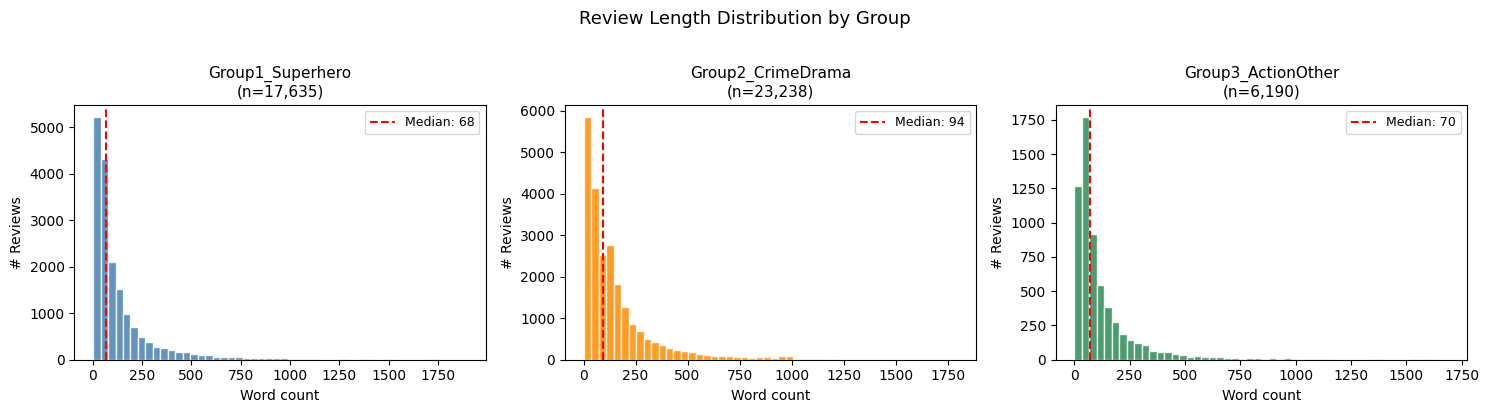

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["steelblue", "darkorange", "seagreen"]

for ax, (group, gdf), color in zip(axes, df.groupby("group"), colors):
    ax.hist(gdf["review_length"], bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{group}\n(n={len(gdf):,})", fontsize=11)
    ax.set_xlabel("Word count")
    ax.set_ylabel("# Reviews")
    median = gdf["review_length"].median()
    ax.axvline(median, color="red", linestyle="--", label=f"Median: {median:.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Review Length Distribution by Group", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/eda_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
print("=== User Rating Distribution by Group ===")
print(df.groupby("group")["User's Rating out of 10"].describe().round(2))

print("\n=== Vocabulary Size per Group ===")
for group, gdf in df.groupby("group"):
    tokens = " ".join(gdf["Review"].astype(str)).lower().split()
    print(f"  {group}: {len(set(tokens)):,} unique tokens")

=== User Rating Distribution by Group ===
                    count unique top   freq
group                                      
Group1_Superhero    17635     11  10   8312
Group2_CrimeDrama   23238     11  10  12491
Group3_ActionOther   6190     11  10   1514

=== Vocabulary Size per Group ===
  Group1_Superhero: 95,251 unique tokens
  Group2_CrimeDrama: 128,564 unique tokens
  Group3_ActionOther: 50,454 unique tokens


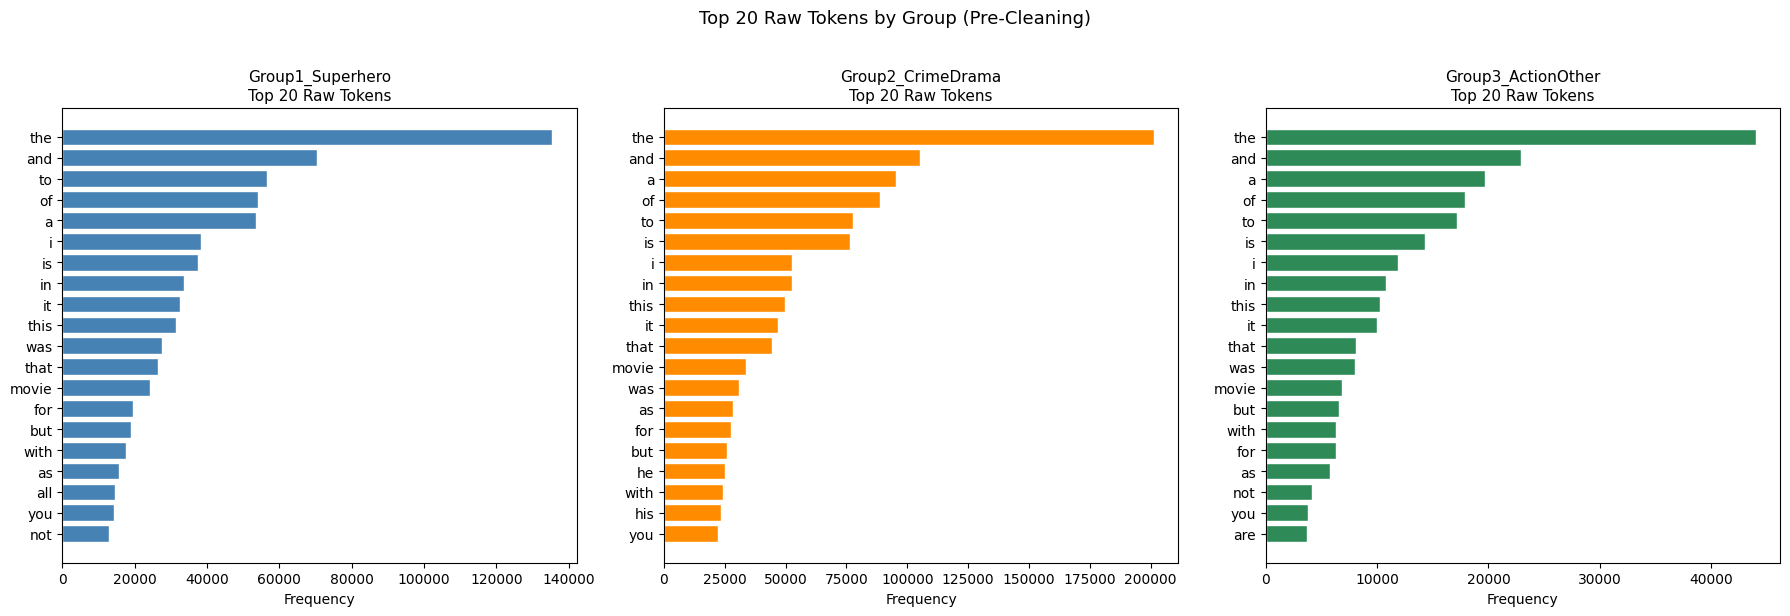

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ["steelblue", "darkorange", "seagreen"]

for ax, (group, gdf), color in zip(axes, df.groupby("group"), colors):
    tokens = " ".join(gdf["Review"].astype(str)).lower().split()
    freq = pd.Series(tokens).value_counts().head(20)
    ax.barh(freq.index[::-1], freq.values[::-1], color=color, edgecolor="white")
    ax.set_title(f"{group}\nTop 20 Raw Tokens", fontsize=11)
    ax.set_xlabel("Frequency")

plt.suptitle("Top 20 Raw Tokens by Group (Pre-Cleaning)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/eda_raw_token_freq.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

custom_stopwords = {
    "movie", "film", "watch", "watched", "watching", "see", "seen",
    "good", "bad", "great", "really", "just", "make", "think",
    "know", "want", "time", "way", "thing", "people", "year",
    "like", "love", "hate", "feel", "felt", "look", "looks",
    "one", "also", "would", "could", "even", "much", "well",
    "little", "lot", "say", "said", "get", "got", "go", "going",
    "come", "take", "give", "new", "old", "big", "long",
    "avenger", "avengers", "spiderman", "spider", "dark", "knight",
    "joker", "pulp", "fiction", "forrest", "gump", "thor", "ragnarok",
    "john", "wick", "morbius", "batman", "marvel", "dc",
    "review", "spoiler", "rating", "star", "point", "recommend",
    "audience", "viewer", "fan", "sequel", "franchise", "series",
}

all_stopwords = STOP_WORDS.union(custom_stopwords)

In [19]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in all_stopwords
        and len(token.lemma_) > 2
        and token.is_alpha
    ]
    return " ".join(tokens)

In [20]:
print("Preprocessing reviews")
df["Review_clean"] = df["Review"].astype(str).apply(preprocess)

print("\n=== Before/After Preprocessing ===")
idx = 100
print(f"BEFORE:\n{df['Review'].iloc[idx][:400]}")
print(f"\nAFTER:\n{df['Review_clean'].iloc[idx][:400]}")

df["clean_length"] = df["Review_clean"].str.split().str.len()
print(f"\nReviews with < 5 tokens: {(df['clean_length'] < 5).sum()}")

df = df[df["clean_length"] >= 5].reset_index(drop=True)
print(f"Final dataset after filtering: {df.shape[0]:,} reviews")

df.to_csv("data/processed/imdb_reviews_clean.csv", index=False)
print("Saved: data/processed/imdb_reviews_clean.csv")

Preprocessing reviews

=== Before/After Preprocessing ===
BEFORE:
When Morbus stabbed the anti morber I felt the ground shake beneath me and I felt an awakening in my mind (it was a subdural hematoma). The post credits scene where Morbius looks at his watch and days "well would you look at that, it's morbin time." And then him and vulture start morbing is so cool I am going to capture various species of bats and eat them so I can be just like Morbius.

AFTER:
morbus stab anti morber ground shake beneath awakening mind subdural hematoma post credit scene day morbin vulture start morbing cool capture specie bat eat

Reviews with < 5 tokens: 3645
Final dataset after filtering: 43,418 reviews
Saved: data/processed/imdb_reviews_clean.csv


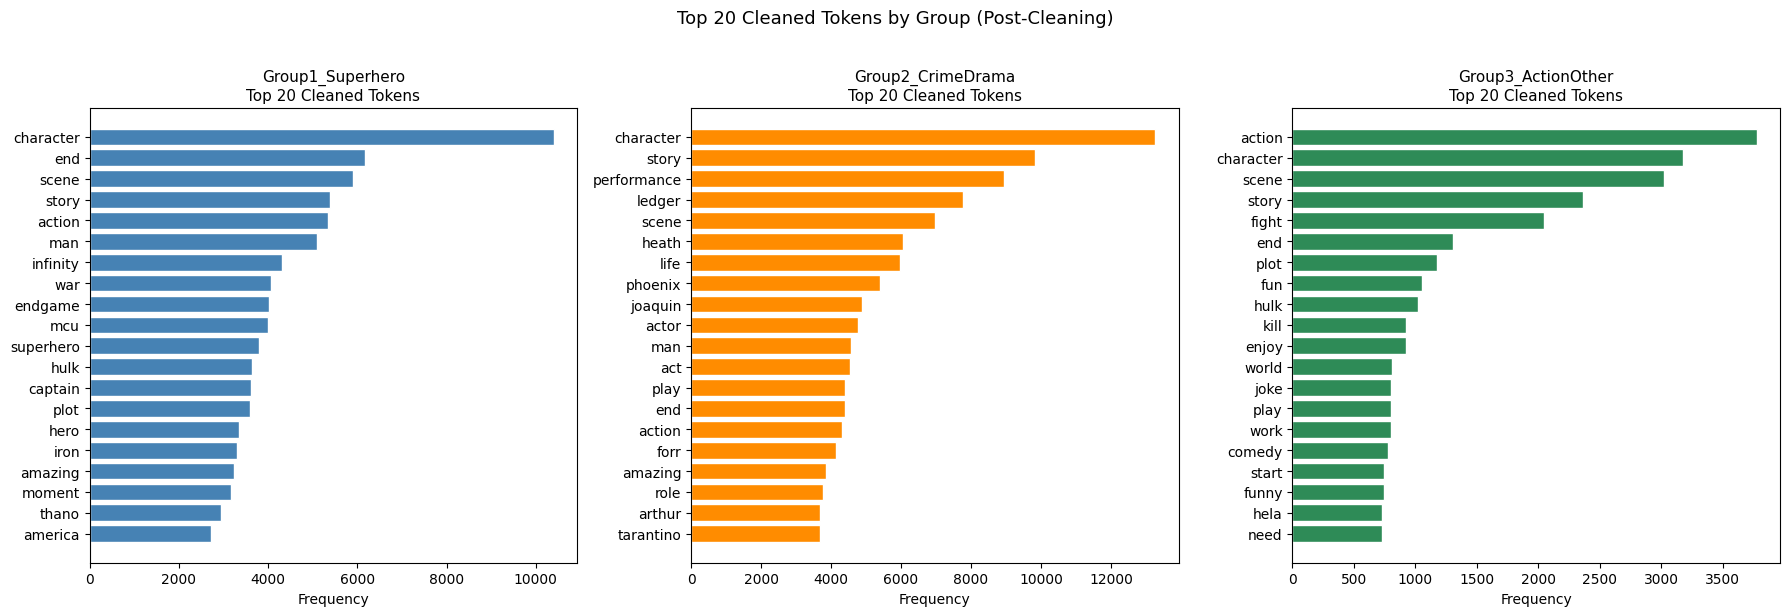

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ["steelblue", "darkorange", "seagreen"]

for ax, (group, gdf), color in zip(axes, df.groupby("group"), colors):
    tokens = " ".join(gdf["Review_clean"].astype(str)).split()
    freq = pd.Series(tokens).value_counts().head(20)
    ax.barh(freq.index[::-1], freq.values[::-1], color=color, edgecolor="white")
    ax.set_title(f"{group}\nTop 20 Cleaned Tokens", fontsize=11)
    ax.set_xlabel("Frequency")

plt.suptitle("Top 20 Cleaned Tokens by Group (Post-Cleaning)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/eda_clean_token_freq.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
g1 = df[df["group"] == "Group1_Superhero"]["Review_clean"].tolist()
g2 = df[df["group"] == "Group2_CrimeDrama"]["Review_clean"].tolist()
g3 = df[df["group"] == "Group3_ActionOther"]["Review_clean"].tolist()

print(f"Group 1 (Superhero):    {len(g1):,} docs")
print(f"Group 2 (Crime/Drama):  {len(g2):,} docs")
print(f"Group 3 (Action/Other): {len(g3):,} docs")

cv_params = dict(
    max_df=0.90,
    min_df=10,
    max_features=5000,
    ngram_range=(1, 2)
)

cv_g1 = CountVectorizer(**cv_params)
cv_g2 = CountVectorizer(**cv_params)
cv_g3 = CountVectorizer(**cv_params)

dtm_g1 = cv_g1.fit_transform(g1)
dtm_g2 = cv_g2.fit_transform(g2)
dtm_g3 = cv_g3.fit_transform(g3)

print(f"\nDTM shapes:")
print(f"  Group 1: {dtm_g1.shape}")
print(f"  Group 2: {dtm_g2.shape}")
print(f"  Group 3: {dtm_g3.shape}")

print("\n=== Top 20 Tokens by Frequency ===")
for name, cv, dtm in [
    ("Group1_Superhero",   cv_g1, dtm_g1),
    ("Group2_CrimeDrama",  cv_g2, dtm_g2),
    ("Group3_ActionOther", cv_g3, dtm_g3)
]:
    vocab = cv.get_feature_names_out()
    freqs = np.asarray(dtm.sum(axis=0)).flatten()
    top20 = [vocab[i] for i in freqs.argsort()[:-21:-1]]
    print(f"  {name}: {', '.join(top20)}")

Group 1 (Superhero):    16,240 docs
Group 2 (Crime/Drama):  21,303 docs
Group 3 (Action/Other): 5,875 docs

DTM shapes:
  Group 1: (16240, 5000)
  Group 2: (21303, 5000)
  Group 3: (5875, 3835)

=== Top 20 Tokens by Frequency ===
  Group1_Superhero: character, end, scene, story, action, man, infinity, war, endgame, mcu, superhero, hulk, captain, plot, hero, iron, infinity war, amazing, moment, iron man
  Group2_CrimeDrama: character, story, performance, ledger, scene, heath, life, phoenix, heath ledger, joaquin, actor, man, act, play, end, action, forr, amazing, role, arthur
  Group3_ActionOther: action, character, scene, story, fight, end, plot, fun, hulk, kill, enjoy, world, joke, play, work, comedy, start, funny, hela, need


# LDA Topic Modeling

In [23]:
def display_topics(model, feature_names, n_words=20):
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_words-1:-1]]
        print(f"  Topic {idx+1:02d}: {', '.join(top_words)}")

def get_coherence_score(docs_tokenized, model, feature_names, dictionary):
    topics_words = [
        [feature_names[i] for i in t.argsort()[:-21:-1]]
        for t in model.components_
    ]
    cm = CoherenceModel(
        topics=topics_words,
        texts=docs_tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

In [24]:
K_values = [5, 8, 10, 12, 15]

tok_g1 = [doc.split() for doc in g1]
tok_g2 = [doc.split() for doc in g2]
tok_g3 = [doc.split() for doc in g3]

dict_g1 = Dictionary(tok_g1)
dict_g2 = Dictionary(tok_g2)
dict_g3 = Dictionary(tok_g3)

groups = {
    "Group1_Superhero":   (dtm_g1, cv_g1, tok_g1, dict_g1),
    "Group2_CrimeDrama":  (dtm_g2, cv_g2, tok_g2, dict_g2),
    "Group3_ActionOther": (dtm_g3, cv_g3, tok_g3, dict_g3),
}

tuning_results = []

for group_name, (dtm, cv, tok, dictionary) in groups.items():
    vocab = cv.get_feature_names_out()
    print(f"\n{'='*60}")
    print(f"LDA K Tuning — {group_name}")
    print('='*60)

    for k in K_values:
        lda = LatentDirichletAllocation(
            n_components=k,
            max_iter=20,
            learning_method="online",
            random_state=42,
            n_jobs=-1
        )
        lda.fit(dtm)

        coherence = get_coherence_score(tok, lda, vocab, dictionary)
        perplexity = lda.perplexity(dtm)

        print(f"  k={k:>2} | Coherence: {coherence:.4f} | Perplexity: {perplexity:.1f}")

        tuning_results.append({
            "group":      group_name,
            "k":          k,
            "coherence":  coherence,
            "perplexity": perplexity
        })

tuning_df = pd.DataFrame(tuning_results)
print("\n=== Full Tuning Results ===")
print(tuning_df.to_string(index=False))


LDA K Tuning — Group1_Superhero
  k= 5 | Coherence: 0.5126 | Perplexity: 1458.4
  k= 8 | Coherence: 0.5265 | Perplexity: 1559.2
  k=10 | Coherence: 0.4938 | Perplexity: 1602.1
  k=12 | Coherence: 0.4643 | Perplexity: 1662.2
  k=15 | Coherence: 0.4659 | Perplexity: 1707.1

LDA K Tuning — Group2_CrimeDrama
  k= 5 | Coherence: 0.5354 | Perplexity: 1627.6
  k= 8 | Coherence: 0.4562 | Perplexity: 1744.7
  k=10 | Coherence: 0.4913 | Perplexity: 1753.5
  k=12 | Coherence: 0.5129 | Perplexity: 1765.5
  k=15 | Coherence: 0.4852 | Perplexity: 1854.7

LDA K Tuning — Group3_ActionOther
  k= 5 | Coherence: 0.5610 | Perplexity: 1459.9
  k= 8 | Coherence: 0.5451 | Perplexity: 1530.2
  k=10 | Coherence: 0.5164 | Perplexity: 1576.2
  k=12 | Coherence: 0.4240 | Perplexity: 1611.3
  k=15 | Coherence: 0.4507 | Perplexity: 1678.0

=== Full Tuning Results ===
             group  k  coherence  perplexity
  Group1_Superhero  5   0.512612 1458.402945
  Group1_Superhero  8   0.526496 1559.152632
  Group1_Super

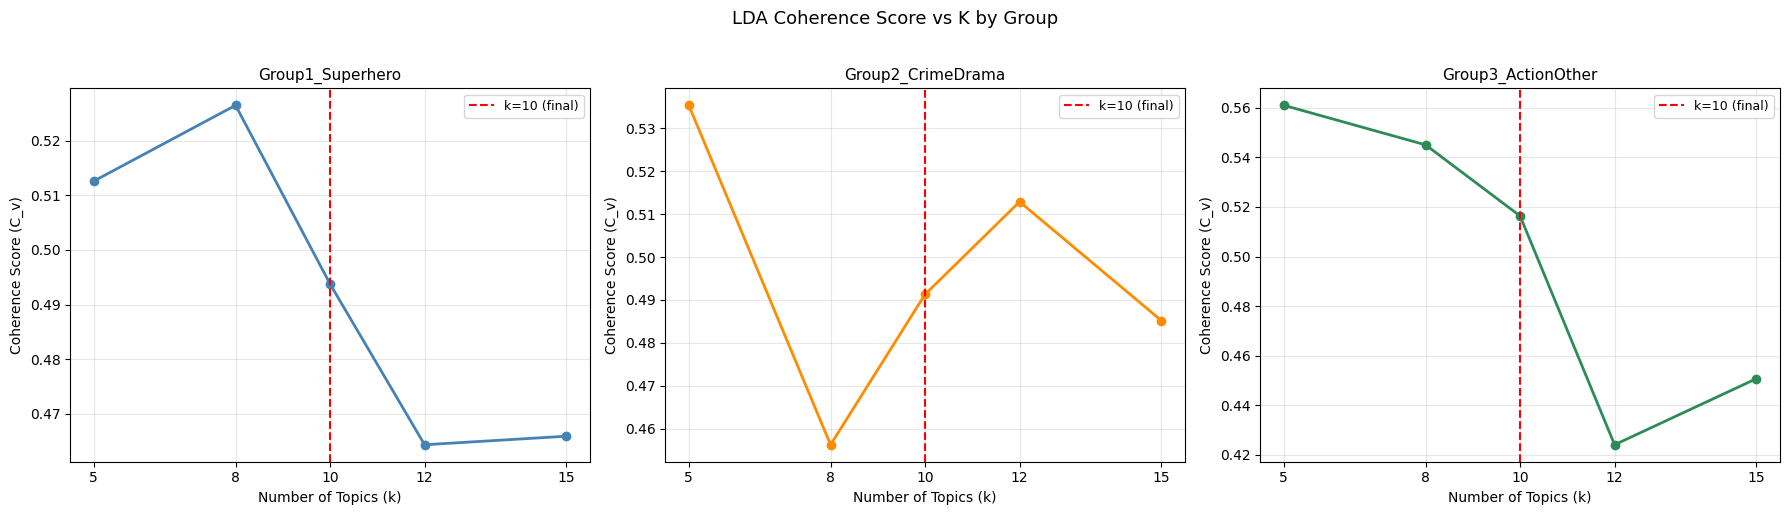

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
group_colors = {
    "Group1_Superhero":   "steelblue",
    "Group2_CrimeDrama":  "darkorange",
    "Group3_ActionOther": "seagreen"
}

for ax, (group_name, gdf) in zip(axes, tuning_df.groupby("group")):
    color = group_colors[group_name]
    ax.plot(gdf["k"], gdf["coherence"], marker="o", color=color, linewidth=2)
    ax.axvline(10, color="red", linestyle="--", label="k=10 (final)")
    ax.set_title(f"{group_name}", fontsize=11)
    ax.set_xlabel("Number of Topics (k)")
    ax.set_ylabel("Coherence Score (C_v)")
    ax.set_xticks(K_values)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("LDA Coherence Score vs K by Group", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/lda_coherence_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
K = 10

tok_g1 = [doc.split() for doc in g1]
tok_g2 = [doc.split() for doc in g2]
tok_g3 = [doc.split() for doc in g3]

dict_g1 = Dictionary(tok_g1)
dict_g2 = Dictionary(tok_g2)
dict_g3 = Dictionary(tok_g3)

groups = {
    "Group1_Superhero":   (dtm_g1, cv_g1, tok_g1, dict_g1),
    "Group2_CrimeDrama":  (dtm_g2, cv_g2, tok_g2, dict_g2),
    "Group3_ActionOther": (dtm_g3, cv_g3, tok_g3, dict_g3),
}

lda_models = {}

for group_name, (dtm, cv, tok, dictionary) in groups.items():
    print(f"\n{'='*60}")
    print(f"LDA | k=10 | {group_name}")
    print('='*60)

    vocab = cv.get_feature_names_out()

    lda = LatentDirichletAllocation(
        n_components=K,
        max_iter=20,
        learning_method="online",
        random_state=42,
        n_jobs=-1
    )
    lda.fit(dtm)

    coherence = get_coherence_score(tok, lda, vocab, dictionary)
    perplexity = lda.perplexity(dtm)

    print(f"  Coherence (C_v): {coherence:.4f}")
    print(f"  Perplexity:      {perplexity:.1f}")
    print(f"\n  Top 20 words per topic:")
    display_topics(lda, vocab, n_words=20)

    pickle.dump(lda, open(f"models/lda_{group_name}_k{K}.pkl", "wb"))
    pickle.dump(cv,  open(f"models/cv_{group_name}.pkl", "wb"))

    lda_models[group_name] = (lda, cv, dtm, tok, dictionary, coherence, perplexity)


LDA | k=10 | Group1_Superhero
  Coherence (C_v): 0.4938
  Perplexity:      1602.1

  Top 20 words per topic:
  Topic 01: comic, book, superhero, comic book, epic, cinematic, universe, incredible, story, cast, nick, conclusion, endgame, nick fury, perfect, cinematic universe, mcu, character, finale, deliver
  Topic 02: amazing, end, cry, perfect, mcu, thank, laugh, endgame, emotional, ending, emotion, experience, expectation, wait, moment, tear, awesome, theater, masterpiece, word
  Topic 03: peter, tom, holland, home, villain, tom holland, strange, andrew, tobey, parker, mcu, peter parker, scene, garfield, character, maguire, amazing, goblin, doctor, multiverse
  Topic 04: character, action, story, scene, plot, effect, act, superhero, expect, hour, fun, moment, bit, enjoy, cgi, actor, special, work, high, slow
  Topic 05: america, captain america, captain, fight, hawkeye, earth, banner, save, villain, battle, power, world, team, shield, use, army, alien, stark, try, guy
  Topic 06: he

In [27]:
K = 10

# Additional stopwords to remove noise terms visible in topic output
extra_stopwords = {
    "end", "guy", "man", "life", "world", "use", "work", "need",
    "happen", "find", "mean", "actually", "let", "try", "bit",
    "pretty", "overall", "far", "second", "instead", "minute",
    "different", "main", "set", "bring", "create", "tell", "play",
    "high", "low", "back", "right", "left", "put", "run", "start",
    "stop", "turn", "ask", "show", "seem", "real", "true", "sure",
    "non", "min", "check", "bar", "night", "day", "word", "hour",
    "human", "woman", "live", "change", "rule", "sell", "mark",
    "ticket", "finally", "wait", "lose", "question", "future",
    "past", "happen", "cause", "reason", "kind", "maybe", "leave",
    "believe", "understand", "act", "expect", "enjoy", "content"
}

all_stopwords_updated = all_stopwords.union(extra_stopwords)

def preprocess_updated(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in all_stopwords_updated
        and len(token.lemma_) > 2
        and token.is_alpha
    ]
    return " ".join(tokens)

print("Re-preprocessing with updated stopwords...")
df["Review_clean"] = df["Review"].astype(str).apply(preprocess_updated)
df["clean_length"] = df["Review_clean"].str.split().str.len()
df = df[df["clean_length"] >= 5].reset_index(drop=True)
print(f"Docs after filter: {df.shape[0]:,}")

g1 = df[df["group"] == "Group1_Superhero"]["Review_clean"].tolist()
g2 = df[df["group"] == "Group2_CrimeDrama"]["Review_clean"].tolist()
g3 = df[df["group"] == "Group3_ActionOther"]["Review_clean"].tolist()

cv_params = dict(max_df=0.90, min_df=15, max_features=5000, ngram_range=(1, 2))

cv_g1 = CountVectorizer(**cv_params)
cv_g2 = CountVectorizer(**cv_params)
cv_g3 = CountVectorizer(**cv_params)

dtm_g1 = cv_g1.fit_transform(g1)
dtm_g2 = cv_g2.fit_transform(g2)
dtm_g3 = cv_g3.fit_transform(g3)

tok_g1 = [doc.split() for doc in g1]
tok_g2 = [doc.split() for doc in g2]
tok_g3 = [doc.split() for doc in g3]

dict_g1 = Dictionary(tok_g1)
dict_g2 = Dictionary(tok_g2)
dict_g3 = Dictionary(tok_g3)

groups = {
    "Group1_Superhero":   (dtm_g1, cv_g1, tok_g1, dict_g1),
    "Group2_CrimeDrama":  (dtm_g2, cv_g2, tok_g2, dict_g2),
    "Group3_ActionOther": (dtm_g3, cv_g3, tok_g3, dict_g3),
}

lda_models = {}

for group_name, (dtm, cv, tok, dictionary) in groups.items():
    print(f"\n{'='*60}")
    print(f"LDA | k=10 | {group_name}")
    print('='*60)

    vocab = cv.get_feature_names_out()

    lda = LatentDirichletAllocation(
        n_components=K,
        max_iter=50,        # increased from 20
        learning_method="online",
        random_state=42,
        n_jobs=-1
    )
    lda.fit(dtm)

    coherence = get_coherence_score(tok, lda, vocab, dictionary)
    perplexity = lda.perplexity(dtm)

    print(f"  Coherence (C_v): {coherence:.4f}")
    print(f"  Perplexity:      {perplexity:.1f}")
    print(f"\n  Top 20 words per topic:")
    display_topics(lda, vocab, n_words=20)

    pickle.dump(lda, open(f"models/lda_{group_name}_k{K}.pkl", "wb"))
    pickle.dump(cv,  open(f"models/cv_{group_name}.pkl", "wb"))

    lda_models[group_name] = (lda, cv, dtm, tok, dictionary, coherence, perplexity)

Re-preprocessing with updated stopwords...
Docs after filter: 42,283

LDA | k=10 | Group1_Superhero
  Coherence (C_v): 0.5119
  Perplexity:      1670.0

  Top 20 words per topic:
  Topic 01: amazing, ending, perfect, sad, thank, endgame, happy, epic, mcu, emotion, awesome, cry, absolutely, emotional, tear, worth, beautiful, deserve, definitely, hope
  Topic 02: age, twist, cinema, team, ultron, meet, suspense, battle scene, age ultron, character, hold, multiple, plot twist, plot, friendly, produce, release, cheer, adventure, range
  Topic 03: superhero, comic, hero, book, action, comic book, loki, super, effect, chris, special, iron, team, special effect, fury, super hero, comic_strip, nick, hemsworth, nick fury
  Topic 04: scene, action, laugh, cry, moment, fight, action scene, emotional, fight scene, theater, credit, theatre, experience, cheer, amazing, funny, laugh cry, awesome, half, cinema
  Topic 05: character, stone, story, scene, universe, plot, travel, endgame, problem, battle

In [28]:
print("\n=== LDA Model Summary ===")
print(f"{'Group':<25} {'K':>4} {'Coherence':>12} {'Perplexity':>12}")
print("-" * 55)
for group_name, (*_, coherence, perplexity) in lda_models.items():
    print(f"{group_name:<25} {K:>4} {coherence:>12.4f} {perplexity:>12.1f}")


=== LDA Model Summary ===
Group                        K    Coherence   Perplexity
-------------------------------------------------------
Group1_Superhero            10       0.5119       1670.0
Group2_CrimeDrama           10       0.5311       1786.0
Group3_ActionOther          10       0.5490       1217.3


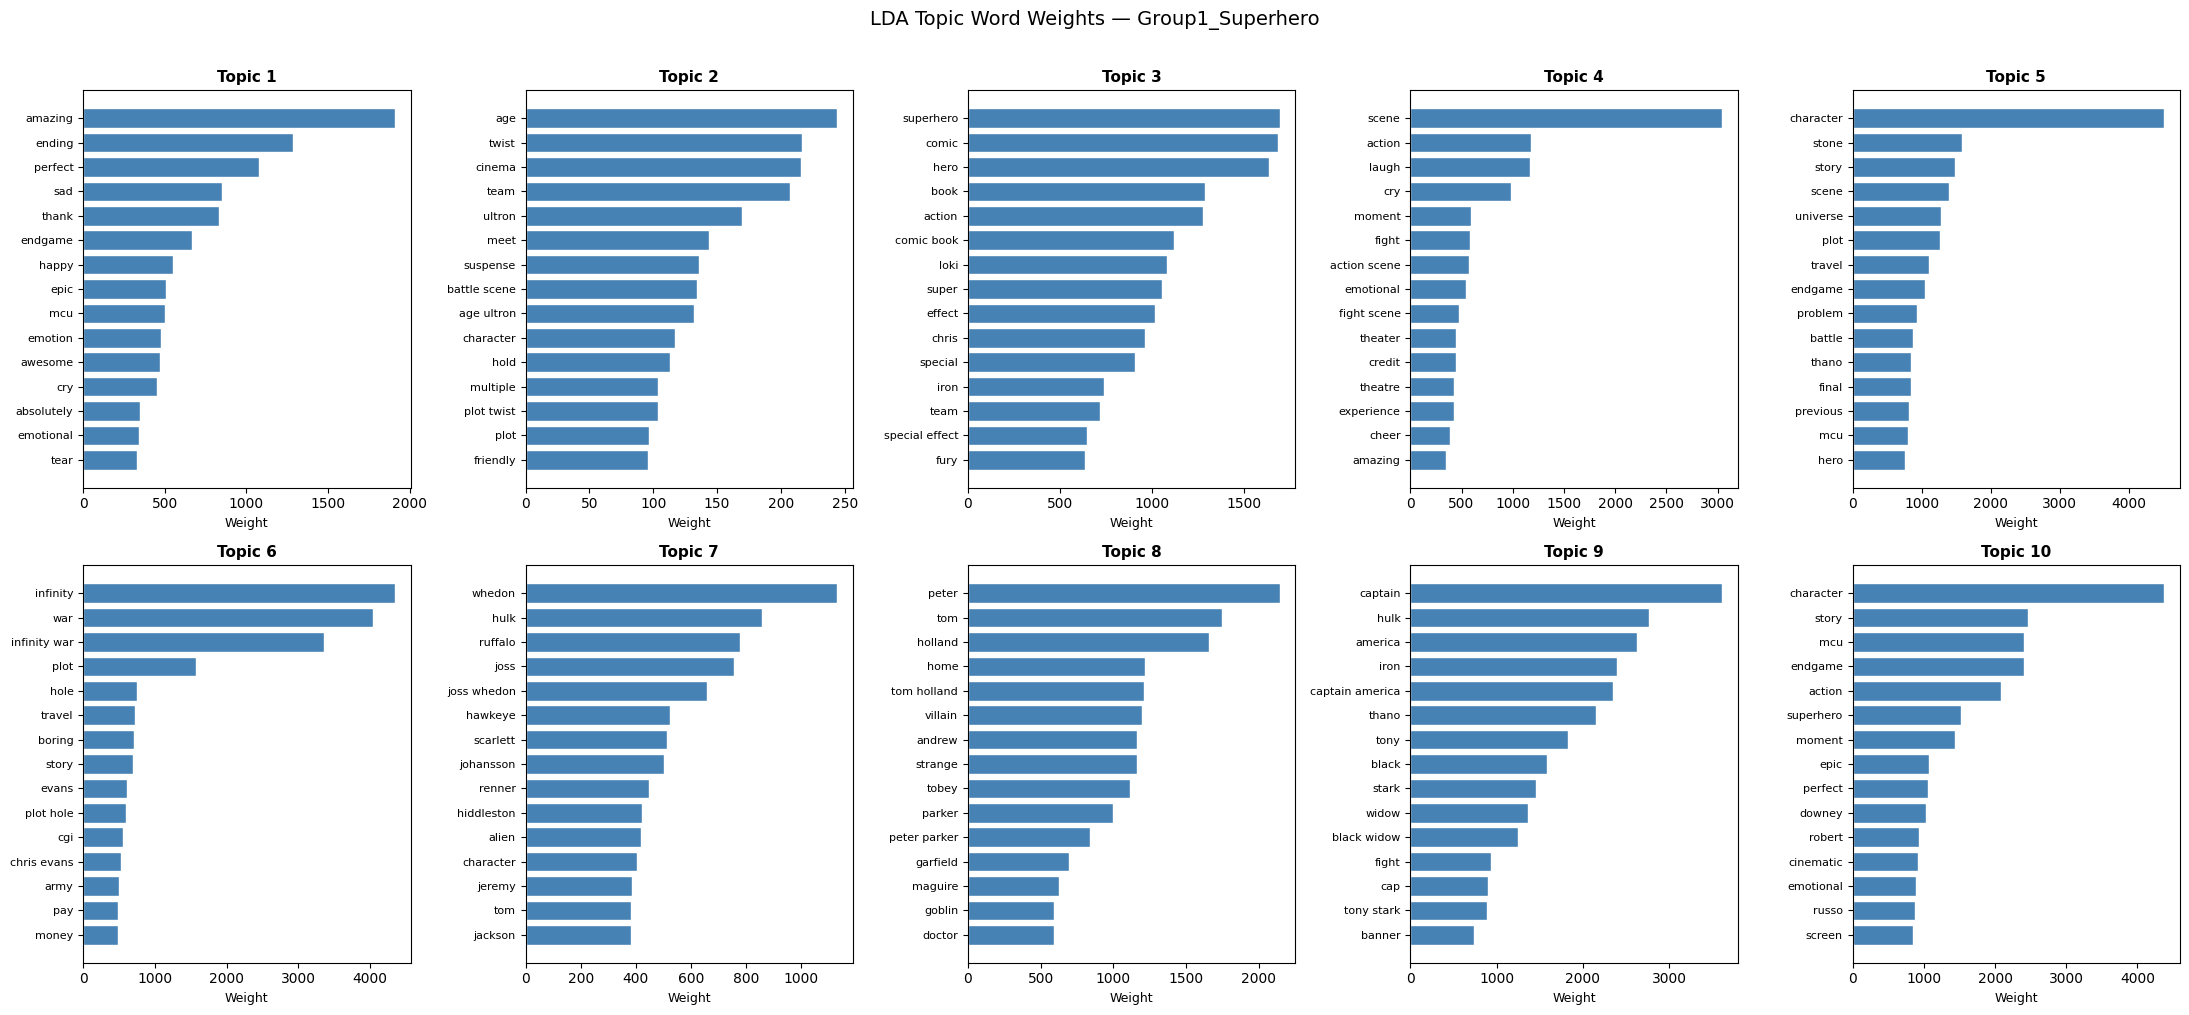

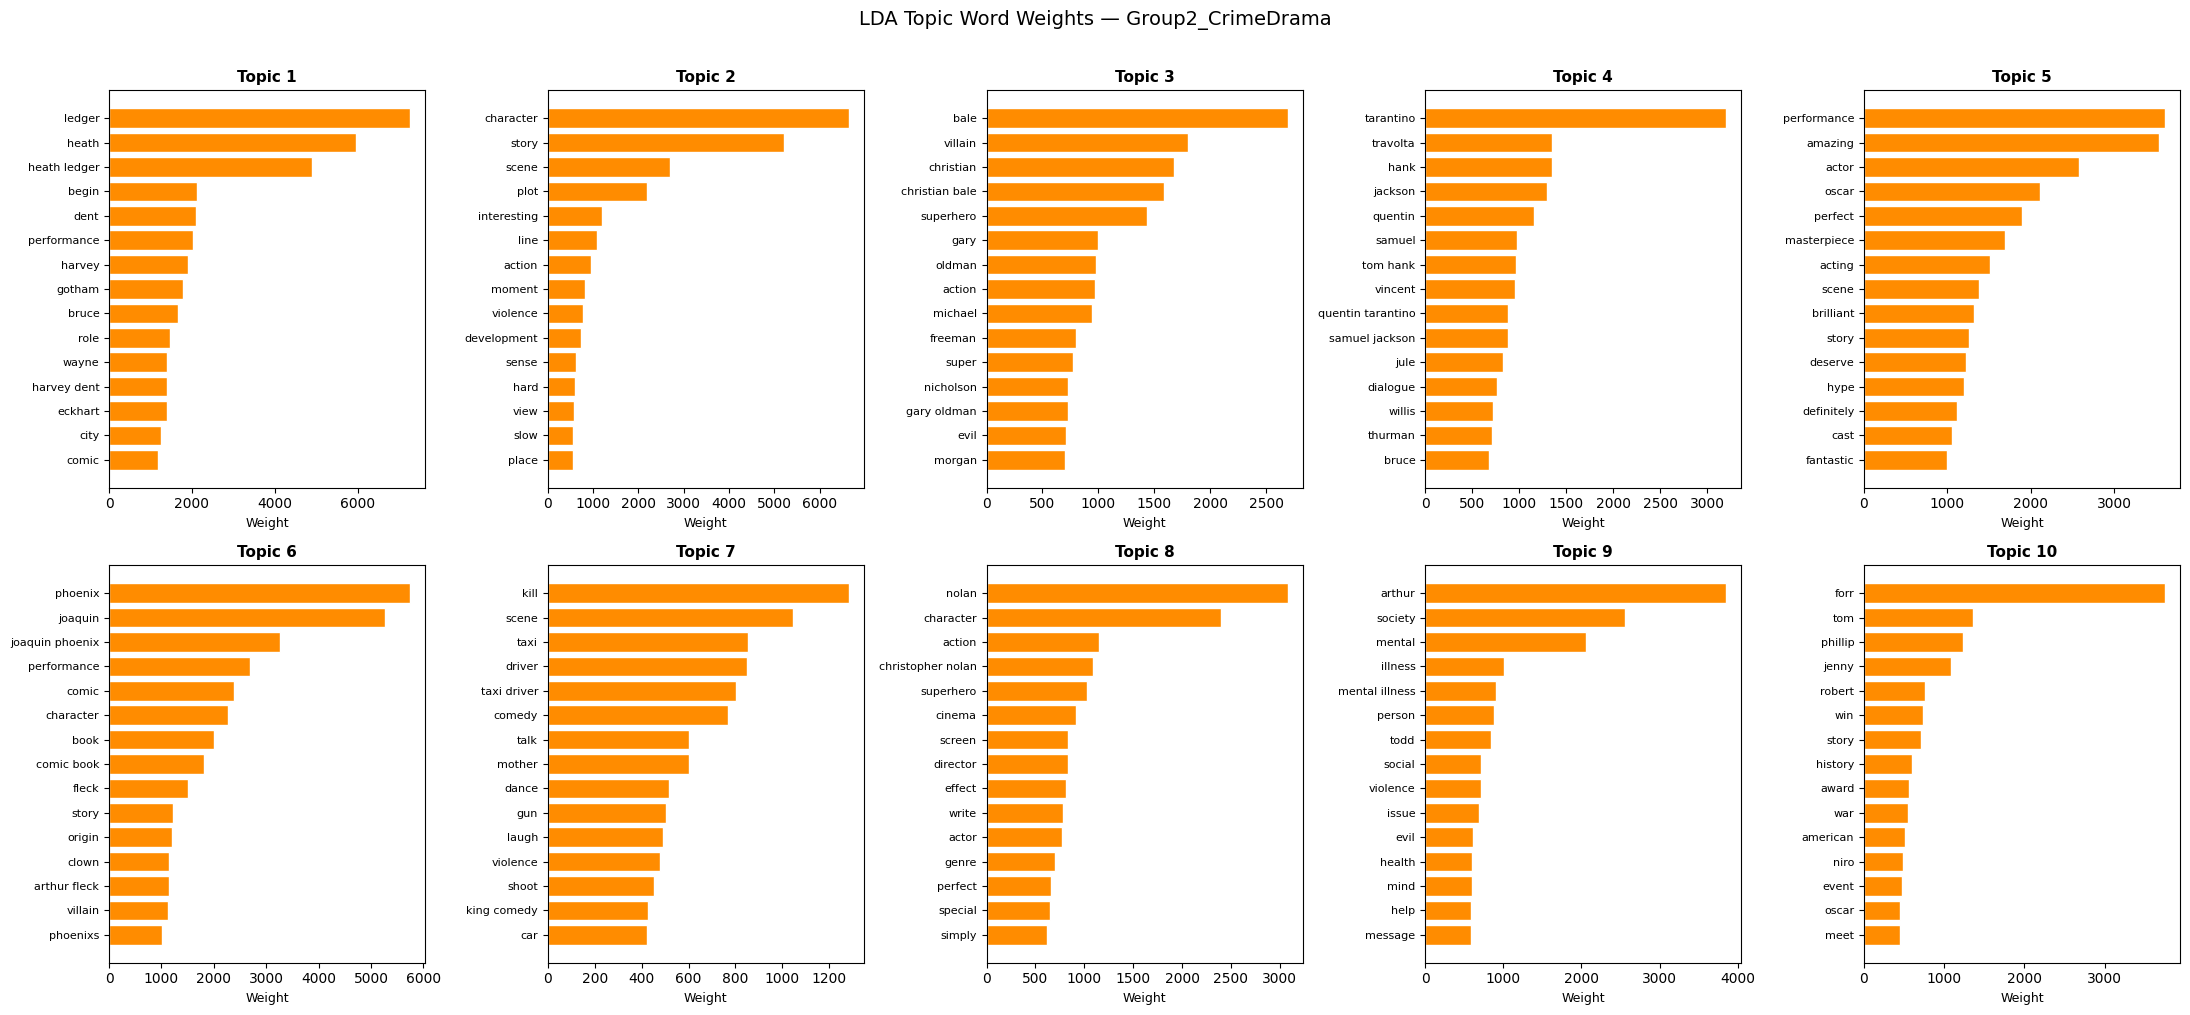

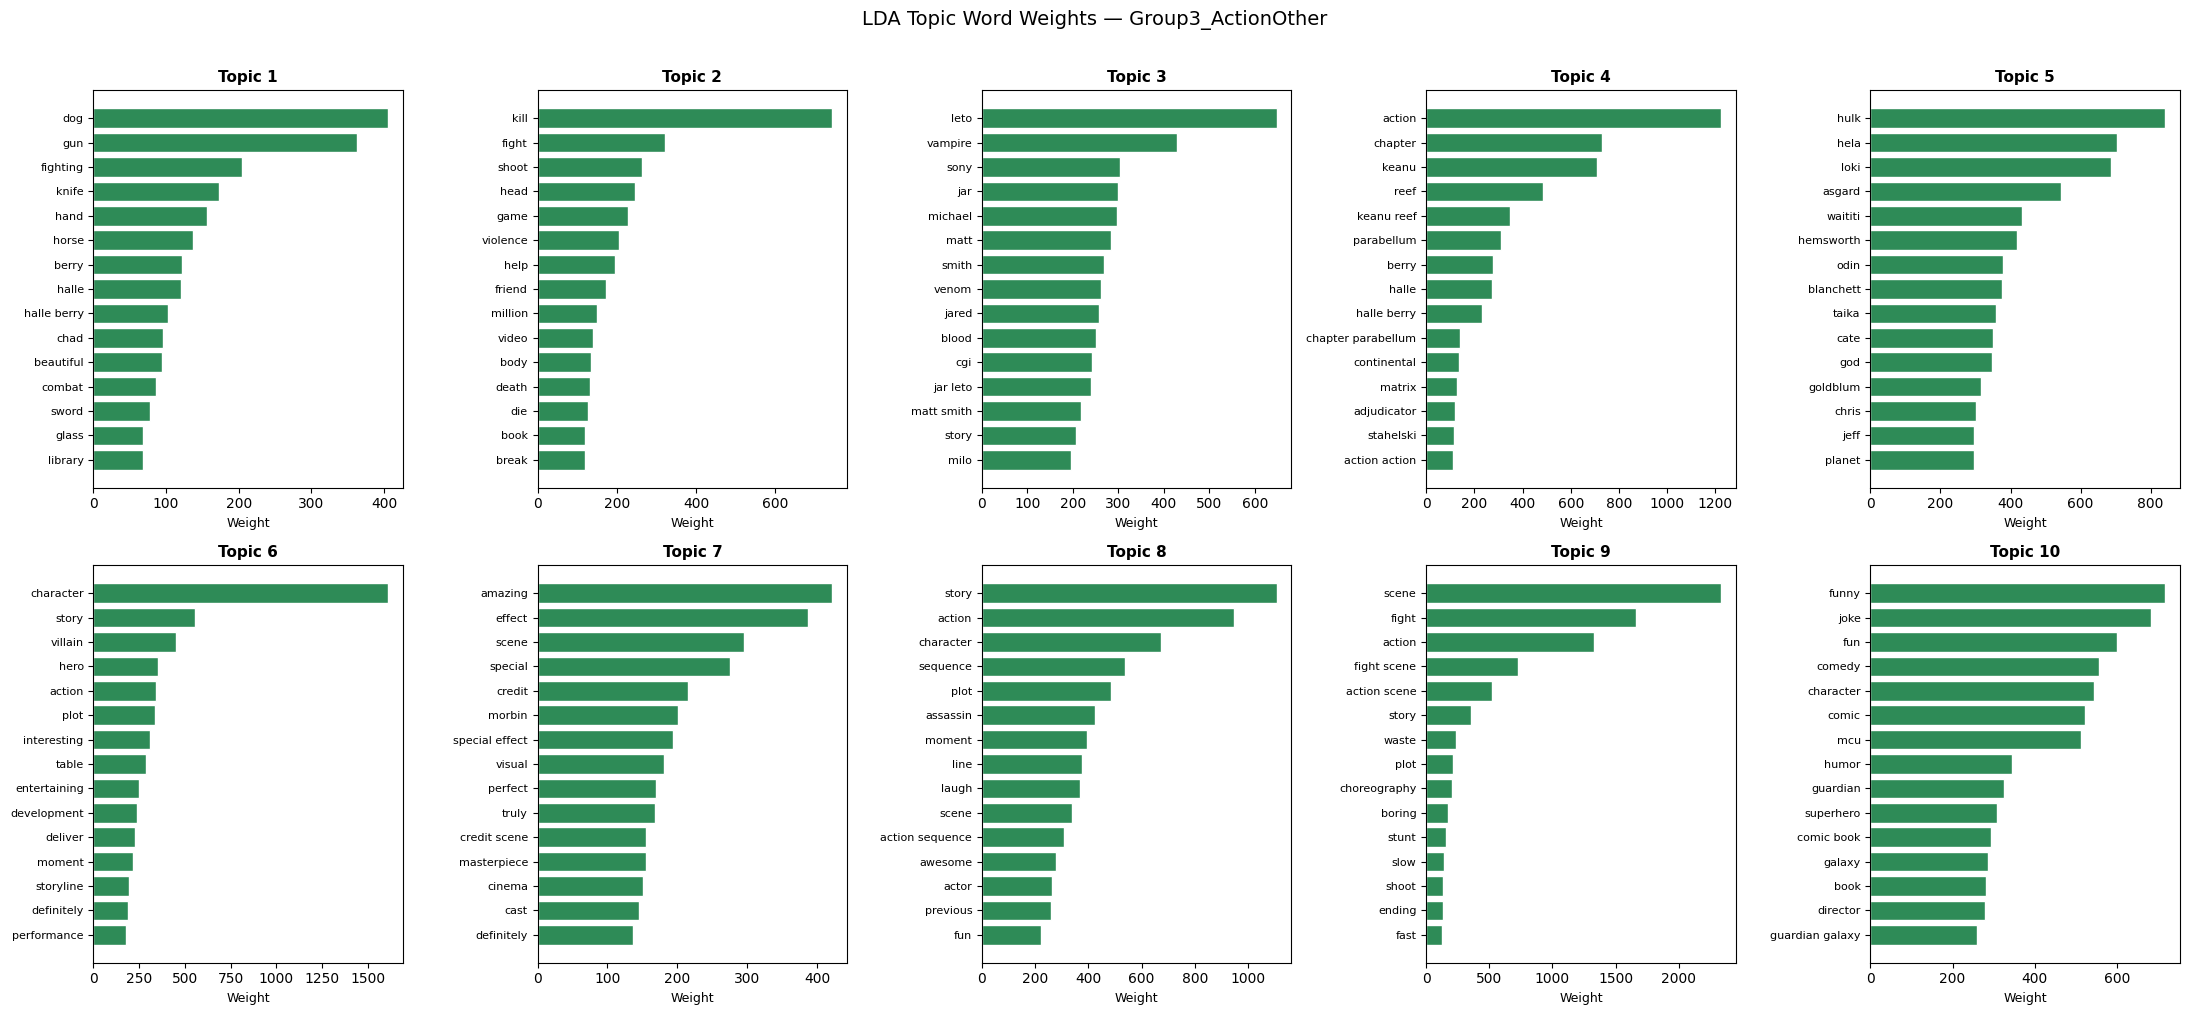

In [29]:
for group_name, (lda, cv, dtm, tok, dictionary, _, _) in lda_models.items():
    vocab = cv.get_feature_names_out()

    group_colors = {
        "Group1_Superhero":   "steelblue",
        "Group2_CrimeDrama":  "darkorange",
        "Group3_ActionOther": "seagreen"
    }
    color = group_colors[group_name]

    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.flatten()

    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[:-16:-1]
        top_words = [vocab[i] for i in top_indices]
        top_weights = [topic[i] for i in top_indices]

        axes[topic_idx].barh(
            top_words[::-1], top_weights[::-1],
            color=color, edgecolor="white"
        )
        axes[topic_idx].set_title(f"Topic {topic_idx+1}", fontsize=11, fontweight="bold")
        axes[topic_idx].set_xlabel("Weight", fontsize=9)
        axes[topic_idx].tick_params(axis='y', labelsize=8)

    plt.suptitle(f"LDA Topic Word Weights — {group_name}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"figures/lda_topics_{group_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# LDA Topic Names by Group (k=10)

---

## Group 1 – Superhero

| Topic | Name |
|-------|------|
| Topic 01 | Emotional Praise |
| Topic 02 | Ultron Twists |
| Topic 03 | Comic Heroes |
| Topic 04 | Scene Reactions |
| Topic 05 | Story Universe |
| Topic 06 | Infinity Holes |
| Topic 07 | Whedon Cast |
| Topic 08 | Spider-Man |
| Topic 09 | Core Avengers |
| Topic 10 | MCU Legacy |

---

## Group 2 – Crime Drama

| Topic | Name |
|-------|------|
| Topic 01 | Ledger's Joker |
| Topic 02 | Plot Critique |
| Topic 03 | Bale's Batman |
| Topic 04 | Tarantino Cast |
| Topic 05 | Oscar Performances |
| Topic 06 | Phoenix's Joker |
| Topic 07 | Taxi Driver |
| Topic 08 | Nolan's Vision |
| Topic 09 | Mental Illness |
| Topic 10 | Forrest Gump |

---

## Group 3 – Action / Other

| Topic | Name |
|-------|------|
| Topic 01 | Hand Combat |
| Topic 02 | Lethal Action |
| Topic 03 | Leto's Morbius |
| Topic 04 | John Wick |
| Topic 05 | Ragnarok Cast |
| Topic 06 | Hero Dynamics |
| Topic 07 | Visual Effects |
| Topic 08 | Action Story |
| Topic 09 | Fight Scenes |
| Topic 10 | MCU Comedy |

# NMF Topic Modeling

In [30]:
from sklearn.decomposition import NMF

def get_reconstruction_error(model, dtm):
    return model.reconstruction_err_

In [31]:
from gensim.models.coherencemodel import CoherenceModel

def get_coherence_score(tokenized_docs, nmf_model, vocab, dictionary, top_n=10):
    # Extract top N words per topic
    topics = []
    for topic_idx in range(nmf_model.n_components):
        top_indices = nmf_model.components_[topic_idx].argsort()[::-1][:top_n]
        top_words = [vocab[i] for i in top_indices]
        topics.append(top_words)

    cm = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v',
        processes=1
    )
    return cm.get_coherence()

In [32]:
K_values = [5, 8, 10, 12, 15]

# This code is used to check the topic modeling process for each k-value to check if the code hangs or freezes when modeling

for k in K_values:
    print(f"  Starting k={k}...", flush=True)

    nmf = NMF(
        n_components=k,
        random_state=42,
        init="random",
        max_iter=400,
        alpha_W=0.0001,
        alpha_H=0.0001,
        l1_ratio=0.5
    )

    print(f"  Fitting k={k}...", flush=True)
    nmf.fit(dtm)
    print(f"  Fit done for k={k}.", flush=True)

    print(f"  Computing coherence for k={k}...", flush=True)
    coherence = get_coherence_score(tok, nmf, vocab, dictionary)
    print(f"  Coherence done for k={k}.", flush=True)

  Starting k=5...
  Fitting k=5...
  Fit done for k=5.
  Computing coherence for k=5...
  Coherence done for k=5.
  Starting k=8...
  Fitting k=8...
  Fit done for k=8.
  Computing coherence for k=8...
  Coherence done for k=8.
  Starting k=10...
  Fitting k=10...
  Fit done for k=10.
  Computing coherence for k=10...
  Coherence done for k=10.
  Starting k=12...
  Fitting k=12...
  Fit done for k=12.
  Computing coherence for k=12...
  Coherence done for k=12.
  Starting k=15...
  Fitting k=15...
  Fit done for k=15.
  Computing coherence for k=15...
  Coherence done for k=15.


In [33]:
from sklearn.decomposition import NMF
import pandas as pd

K_values = [5, 8, 10, 12, 15]

# Tokenized corpora
tok_g1 = [doc.split() for doc in g1]
tok_g2 = [doc.split() for doc in g2]
tok_g3 = [doc.split() for doc in g3]

# Gensim dictionaries (for coherence)
dict_g1 = Dictionary(tok_g1)
dict_g2 = Dictionary(tok_g2)
dict_g3 = Dictionary(tok_g3)

groups = {
    "Group1_Superhero":   (dtm_g1, cv_g1, tok_g1, dict_g1),
    "Group2_CrimeDrama":  (dtm_g2, cv_g2, tok_g2, dict_g2),
    "Group3_ActionOther": (dtm_g3, cv_g3, tok_g3, dict_g3),
}

tuning_results_nmf = []

for group_name, (dtm, cv, tok, dictionary) in groups.items():
    vocab = cv.get_feature_names_out()

    print(f"\n{'='*60}")
    print(f"NMF K Tuning — {group_name}")
    print('='*60)

    for k in K_values:
        nmf = NMF(
            n_components=k,
            random_state=42,
            init="random",
            max_iter=400,
            alpha_W=0.0001,    # Regularization for sparsity (W)
            alpha_H=0.0001,    # Regularization for sparsity (H)
            l1_ratio=0.5
        )

        nmf.fit(dtm)

        coherence = get_coherence_score(tok, nmf, vocab, dictionary)


        reconstruction_error = nmf.reconstruction_err_

        print(
            f"  k={k:>2} | "
            f"Coherence: {coherence:.4f} | "
            f"Reconstruction Error: {reconstruction_error:.1f}"
        )

        tuning_results_nmf.append({
            "group": group_name,
            "k": k,
            "coherence": coherence,
            "reconstruction_error": reconstruction_error
        })

tuning_df_nmf = pd.DataFrame(tuning_results_nmf)

print("\n=== Full NMF Tuning Results ===")
print(tuning_df_nmf.to_string(index=False))


NMF K Tuning — Group1_Superhero
  k= 5 | Coherence: 0.6175 | Reconstruction Error: 897.9
  k= 8 | Coherence: 0.6461 | Reconstruction Error: 879.0
  k=10 | Coherence: 0.6569 | Reconstruction Error: 869.8
  k=12 | Coherence: 0.6385 | Reconstruction Error: 861.8
  k=15 | Coherence: 0.6209 | Reconstruction Error: 852.3

NMF K Tuning — Group2_CrimeDrama
  k= 5 | Coherence: 0.7311 | Reconstruction Error: 1100.1
  k= 8 | Coherence: 0.6822 | Reconstruction Error: 1079.8
  k=10 | Coherence: 0.6941 | Reconstruction Error: 1068.3
  k=12 | Coherence: 0.6761 | Reconstruction Error: 1057.5
  k=15 | Coherence: 0.6617 | Reconstruction Error: 1046.0

NMF K Tuning — Group3_ActionOther
  k= 5 | Coherence: 0.7614 | Reconstruction Error: 480.1
  k= 8 | Coherence: 0.7188 | Reconstruction Error: 469.6
  k=10 | Coherence: 0.7061 | Reconstruction Error: 464.0
  k=12 | Coherence: 0.7228 | Reconstruction Error: 459.4
  k=15 | Coherence: 0.6917 | Reconstruction Error: 454.2

=== Full NMF Tuning Results ===
     

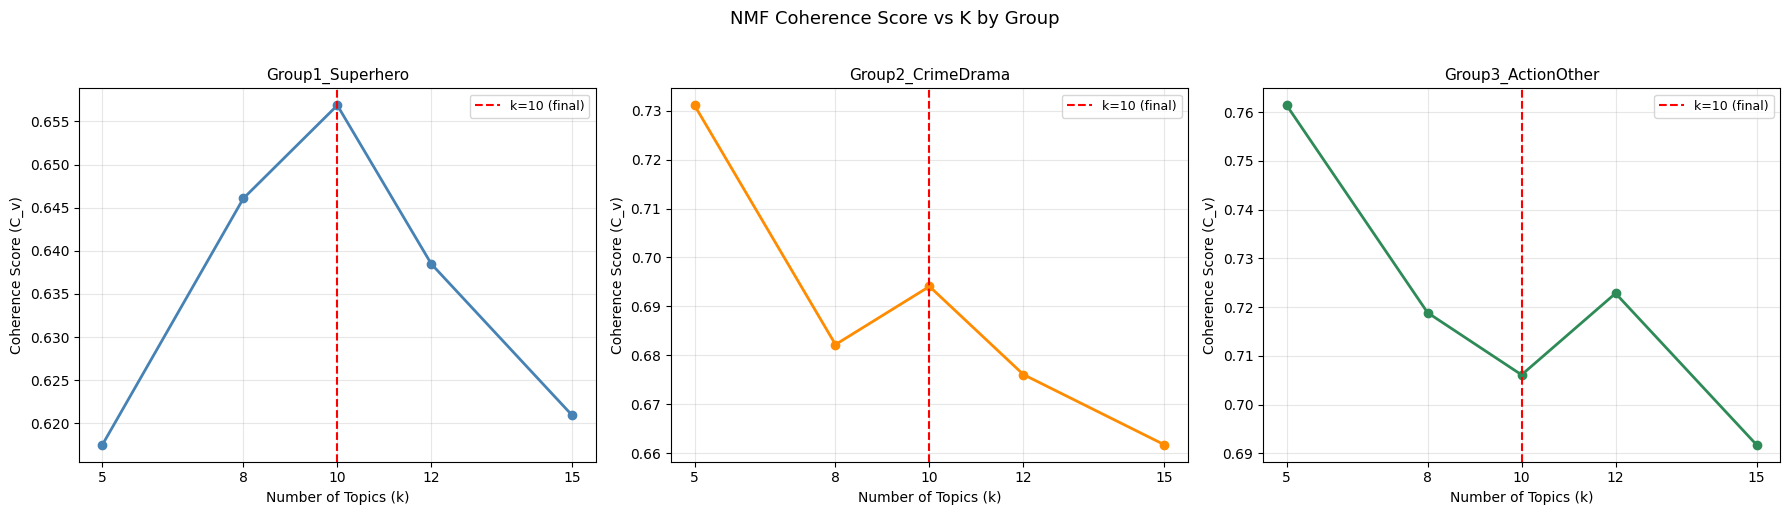

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

group_colors = {
    "Group1_Superhero":   "steelblue",
    "Group2_CrimeDrama":  "darkorange",
    "Group3_ActionOther": "seagreen"
}

for ax, (group_name, gdf) in zip(axes, tuning_df_nmf.groupby("group")):
    color = group_colors[group_name]

    ax.plot(
        gdf["k"],
        gdf["coherence"],
        marker="o",
        color=color,
        linewidth=2
    )

    # Final selected K (adjust if needed)
    ax.axvline(10, color="red", linestyle="--", label="k=10 (final)")

    ax.set_title(group_name, fontsize=11)
    ax.set_xlabel("Number of Topics (k)")
    ax.set_ylabel("Coherence Score (C_v)")
    ax.set_xticks(K_values)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("NMF Coherence Score vs K by Group", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/nmf_coherence_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
import pickle
from sklearn.decomposition import NMF

K = 10

# Tokenized corpora
tok_g1 = [doc.split() for doc in g1]
tok_g2 = [doc.split() for doc in g2]
tok_g3 = [doc.split() for doc in g3]

# Gensim dictionaries (for coherence)
dict_g1 = Dictionary(tok_g1)
dict_g2 = Dictionary(tok_g2)
dict_g3 = Dictionary(tok_g3)

groups = {
    "Group1_Superhero":   (dtm_g1, cv_g1, tok_g1, dict_g1),
    "Group2_CrimeDrama":  (dtm_g2, cv_g2, tok_g2, dict_g2),
    "Group3_ActionOther": (dtm_g3, cv_g3, tok_g3, dict_g3),
}

nmf_models = {}

for group_name, (dtm, cv, tok, dictionary) in groups.items():
    print(f"\n{'='*60}")
    print(f"NMF | k=10 | {group_name}")
    print('='*60)

    vocab = cv.get_feature_names_out()

    nmf = NMF(
        n_components=K,
        random_state=42,
        init="random",
        max_iter=400,
        alpha_W=0.0001,
        alpha_H=0.0001,
        l1_ratio=0.5
    )

    nmf.fit(dtm)

    coherence = get_coherence_score(tok, nmf, vocab, dictionary)

    reconstruction_error = nmf.reconstruction_err_

    print(f"  Coherence (C_v):        {coherence:.4f}")
    print(f"  Reconstruction Error:  {reconstruction_error:.1f}")
    print(f"\n  Top 20 words per topic:")

    display_topics(nmf, vocab, n_words=20)

    # Save models and vectorizers
    pickle.dump(nmf, open(f"models/nmf_{group_name}_k{K}.pkl", "wb"))
    pickle.dump(cv,  open(f"models/cv_{group_name}.pkl", "wb"))

    nmf_models[group_name] = (
        nmf,
        cv,
        dtm,
        tok,
        dictionary,
        coherence,
        reconstruction_error
    )


NMF | k=10 | Group1_Superhero
  Coherence (C_v):        0.6569
  Reconstruction Error:  869.8

  Top 20 words per topic:
  Topic 01: scene, fight, action, fight scene, action scene, battle, final, moment, hulk, funny, credit, joke, emotional, boring, cap, talk, cgi, amazing, especially, cool
  Topic 02: peter, strange, parker, villain, peter parker, spell, goblin, doctor, universe, doctor strange, help, forget, fight, aunt, cure, friend, green, ned, green goblin, home
  Topic 03: character, moment, plot, development, character development, previous, screen, arc, care, fun, interesting, villain, place, emotional, tony, comic, sense, joke, completely, actor
  Topic 04: thano, stone, travel, tony, stark, snap, kill, infinity, nebula, cap, infinity stone, timeline, die, gauntlet, fight, universe, battle, destroy, return, sacrifice
  Topic 05: hulk, loki, superhero, whedon, chris, iron, ruffalo, downey, fury, joss, joss whedon, banner, robert, stark, robert downey, nick, action, team, nick

In [36]:
K = 10

# Additional stopwords to remove noise terms visible in topic output
extra_stopwords = {
    "end", "guy", "man", "life", "world", "use", "work", "need",
    "happen", "find", "mean", "actually", "let", "try", "bit",
    "pretty", "overall", "far", "second", "instead", "minute",
    "different", "main", "set", "bring", "create", "tell", "play",
    "high", "low", "back", "right", "left", "put", "run", "start",
    "stop", "turn", "ask", "show", "seem", "real", "true", "sure",
    "non", "min", "check", "bar", "night", "day", "word", "hour",
    "human", "woman", "live", "change", "rule", "sell", "mark",
    "ticket", "finally", "wait", "lose", "question", "future",
    "past", "happen", "cause", "reason", "kind", "maybe", "leave",
    "believe", "understand", "act", "expect", "enjoy", "content"
}

all_stopwords_updated = all_stopwords.union(extra_stopwords)

def preprocess_updated(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in all_stopwords_updated
        and len(token.lemma_) > 2
        and token.is_alpha
    ]
    return " ".join(tokens)

print("Re-preprocessing with updated stopwords...")
df["Review_clean"] = df["Review"].astype(str).apply(preprocess_updated)
df["clean_length"] = df["Review_clean"].str.split().str.len()
df = df[df["clean_length"] >= 5].reset_index(drop=True)
print(f"Docs after filter: {df.shape[0]:,}")

g1 = df[df["group"] == "Group1_Superhero"]["Review_clean"].tolist()
g2 = df[df["group"] == "Group2_CrimeDrama"]["Review_clean"].tolist()
g3 = df[df["group"] == "Group3_ActionOther"]["Review_clean"].tolist()

cv_params = dict(max_df=0.90, min_df=15, max_features=5000, ngram_range=(1, 2))

cv_g1 = CountVectorizer(**cv_params)
cv_g2 = CountVectorizer(**cv_params)
cv_g3 = CountVectorizer(**cv_params)

dtm_g1 = cv_g1.fit_transform(g1)
dtm_g2 = cv_g2.fit_transform(g2)
dtm_g3 = cv_g3.fit_transform(g3)

tok_g1 = [doc.split() for doc in g1]
tok_g2 = [doc.split() for doc in g2]
tok_g3 = [doc.split() for doc in g3]

dict_g1 = Dictionary(tok_g1)
dict_g2 = Dictionary(tok_g2)
dict_g3 = Dictionary(tok_g3)

groups = {
    "Group1_Superhero":   (dtm_g1, cv_g1, tok_g1, dict_g1),
    "Group2_CrimeDrama":  (dtm_g2, cv_g2, tok_g2, dict_g2),
    "Group3_ActionOther": (dtm_g3, cv_g3, tok_g3, dict_g3),
}

nmf_models = {}

for group_name, (dtm, cv, tok, dictionary) in groups.items():
    print(f"\n{'='*60}")
    print(f"NMF | k=10 | {group_name}")
    print('='*60)

    vocab = cv.get_feature_names_out()

    nmf = NMF(
        n_components=K,
        init="random",
        max_iter=400,
        random_state=42,
        alpha_W=0.0001,
        alpha_H=0.0001,
        l1_ratio=0.5
    )
    nmf.fit(dtm)

    coherence = get_coherence_score(tok, nmf, vocab, dictionary)
    reconstruction_error = nmf.reconstruction_err_

    print(f"  Coherence (C_v): {coherence:.4f}")
    print(f"  Reconstruction Error: {reconstruction_error:.1f}")
    print(f"\n  Top 20 words per topic:")
    display_topics(nmf, vocab, n_words=20)

    pickle.dump(nmf, open(f"models/nmf_{group_name}_k{K}.pkl", "wb"))
    pickle.dump(cv,  open(f"models/cv_{group_name}.pkl", "wb"))

    nmf_models[group_name] = (
        nmf, cv, dtm, tok, dictionary, coherence, reconstruction_error
    )

Re-preprocessing with updated stopwords...
Docs after filter: 42,283

NMF | k=10 | Group1_Superhero
  Coherence (C_v): 0.6569
  Reconstruction Error: 869.8

  Top 20 words per topic:
  Topic 01: scene, fight, action, fight scene, action scene, battle, final, moment, hulk, funny, credit, joke, emotional, boring, cap, talk, cgi, amazing, especially, cool
  Topic 02: peter, strange, parker, villain, peter parker, spell, goblin, doctor, universe, doctor strange, help, forget, fight, aunt, cure, friend, green, ned, green goblin, home
  Topic 03: character, moment, plot, development, character development, previous, screen, arc, care, fun, interesting, villain, place, emotional, tony, comic, sense, joke, completely, actor
  Topic 04: thano, stone, travel, tony, stark, snap, kill, infinity, nebula, cap, infinity stone, timeline, die, gauntlet, fight, universe, battle, destroy, return, sacrifice
  Topic 05: hulk, loki, superhero, whedon, chris, iron, ruffalo, downey, fury, joss, joss whedon, b

In [37]:
print("\n=== NMF Model Summary ===")
print(f"{'Group':<25} {'K':>4} {'Coherence':>12} {'Reconst Err':>12}")
print("-" * 55)

for group_name, (*_, coherence, reconstruction_error) in nmf_models.items():
    print(f"{group_name:<25} {K:>4} {coherence:>12.4f} {reconstruction_error:>12.1f}")


=== NMF Model Summary ===
Group                        K    Coherence  Reconst Err
-------------------------------------------------------
Group1_Superhero            10       0.6569        869.8
Group2_CrimeDrama           10       0.6941       1068.3
Group3_ActionOther          10       0.7061        464.0


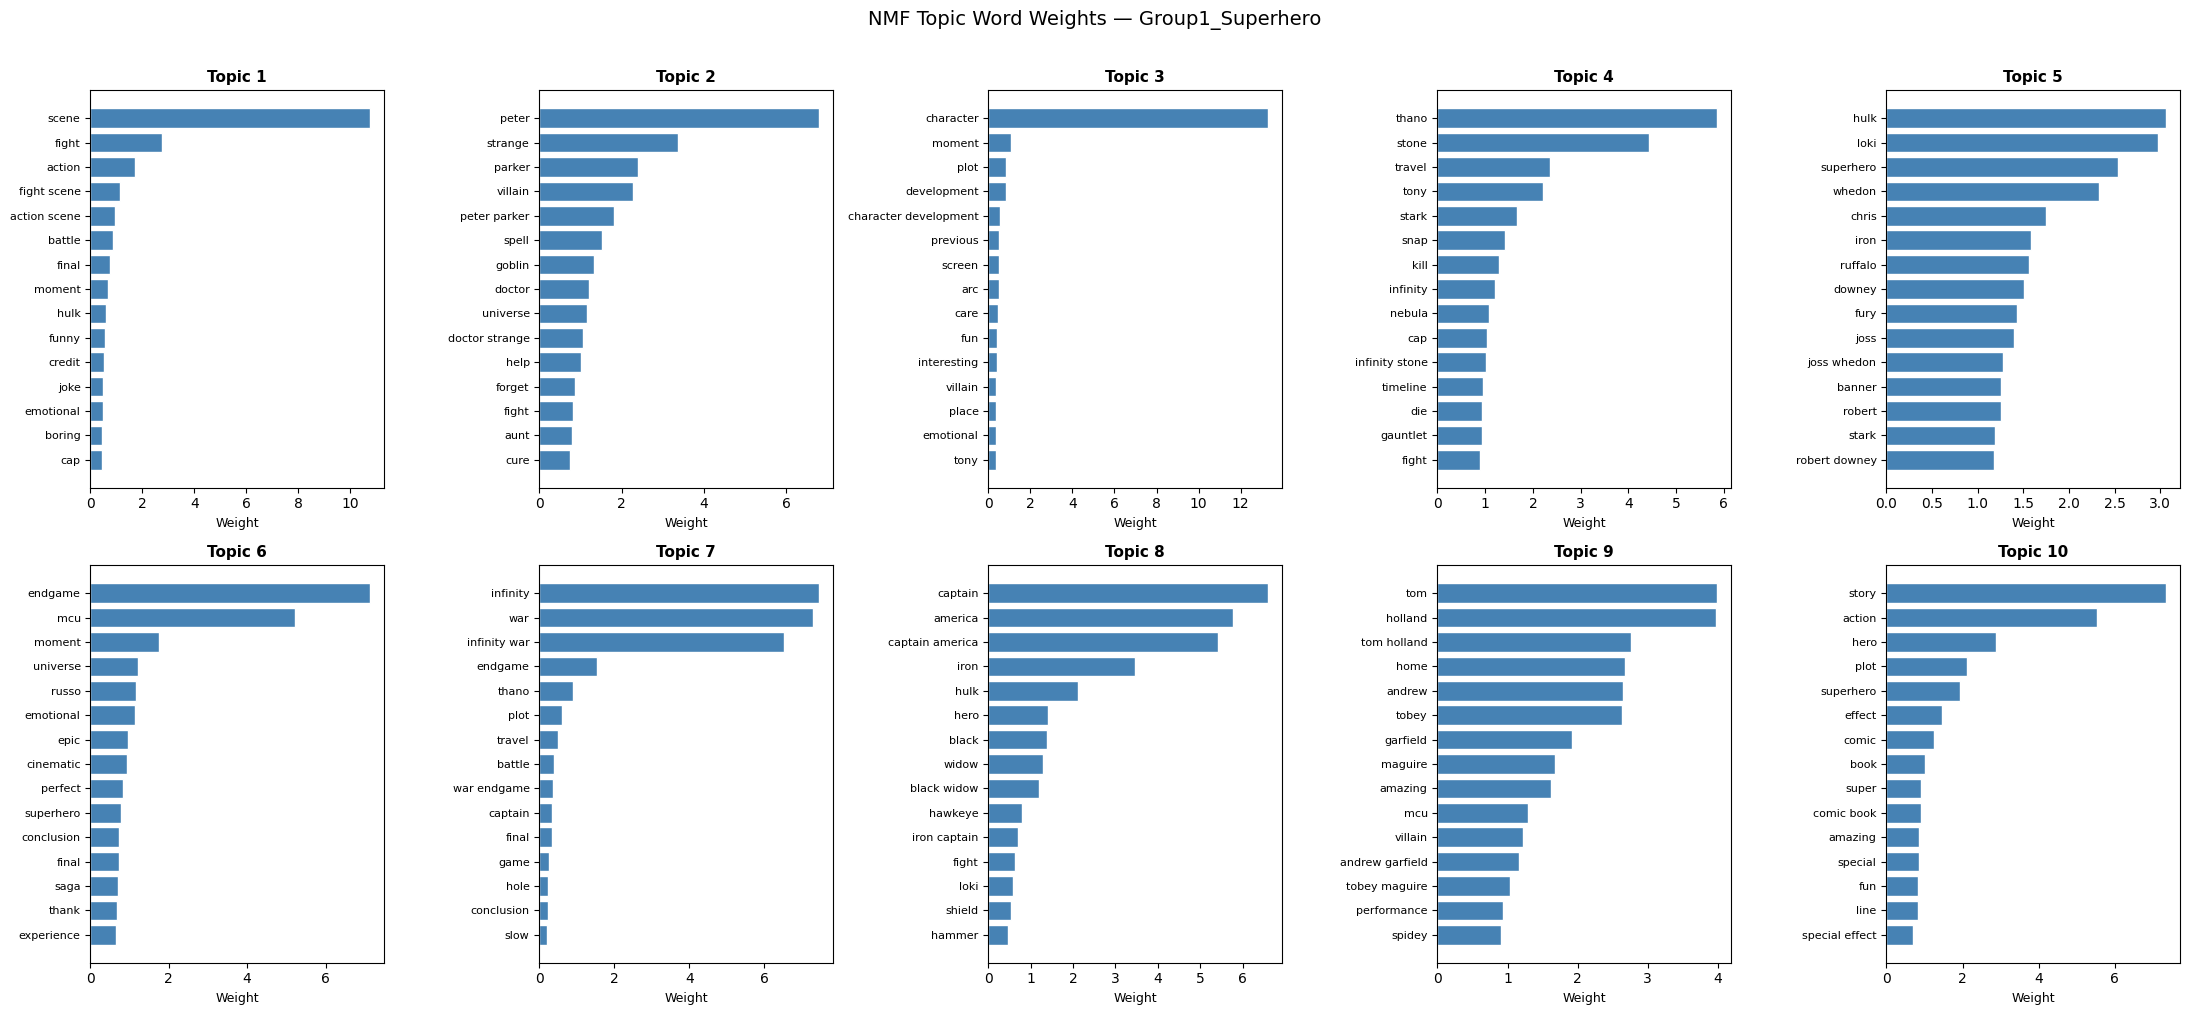

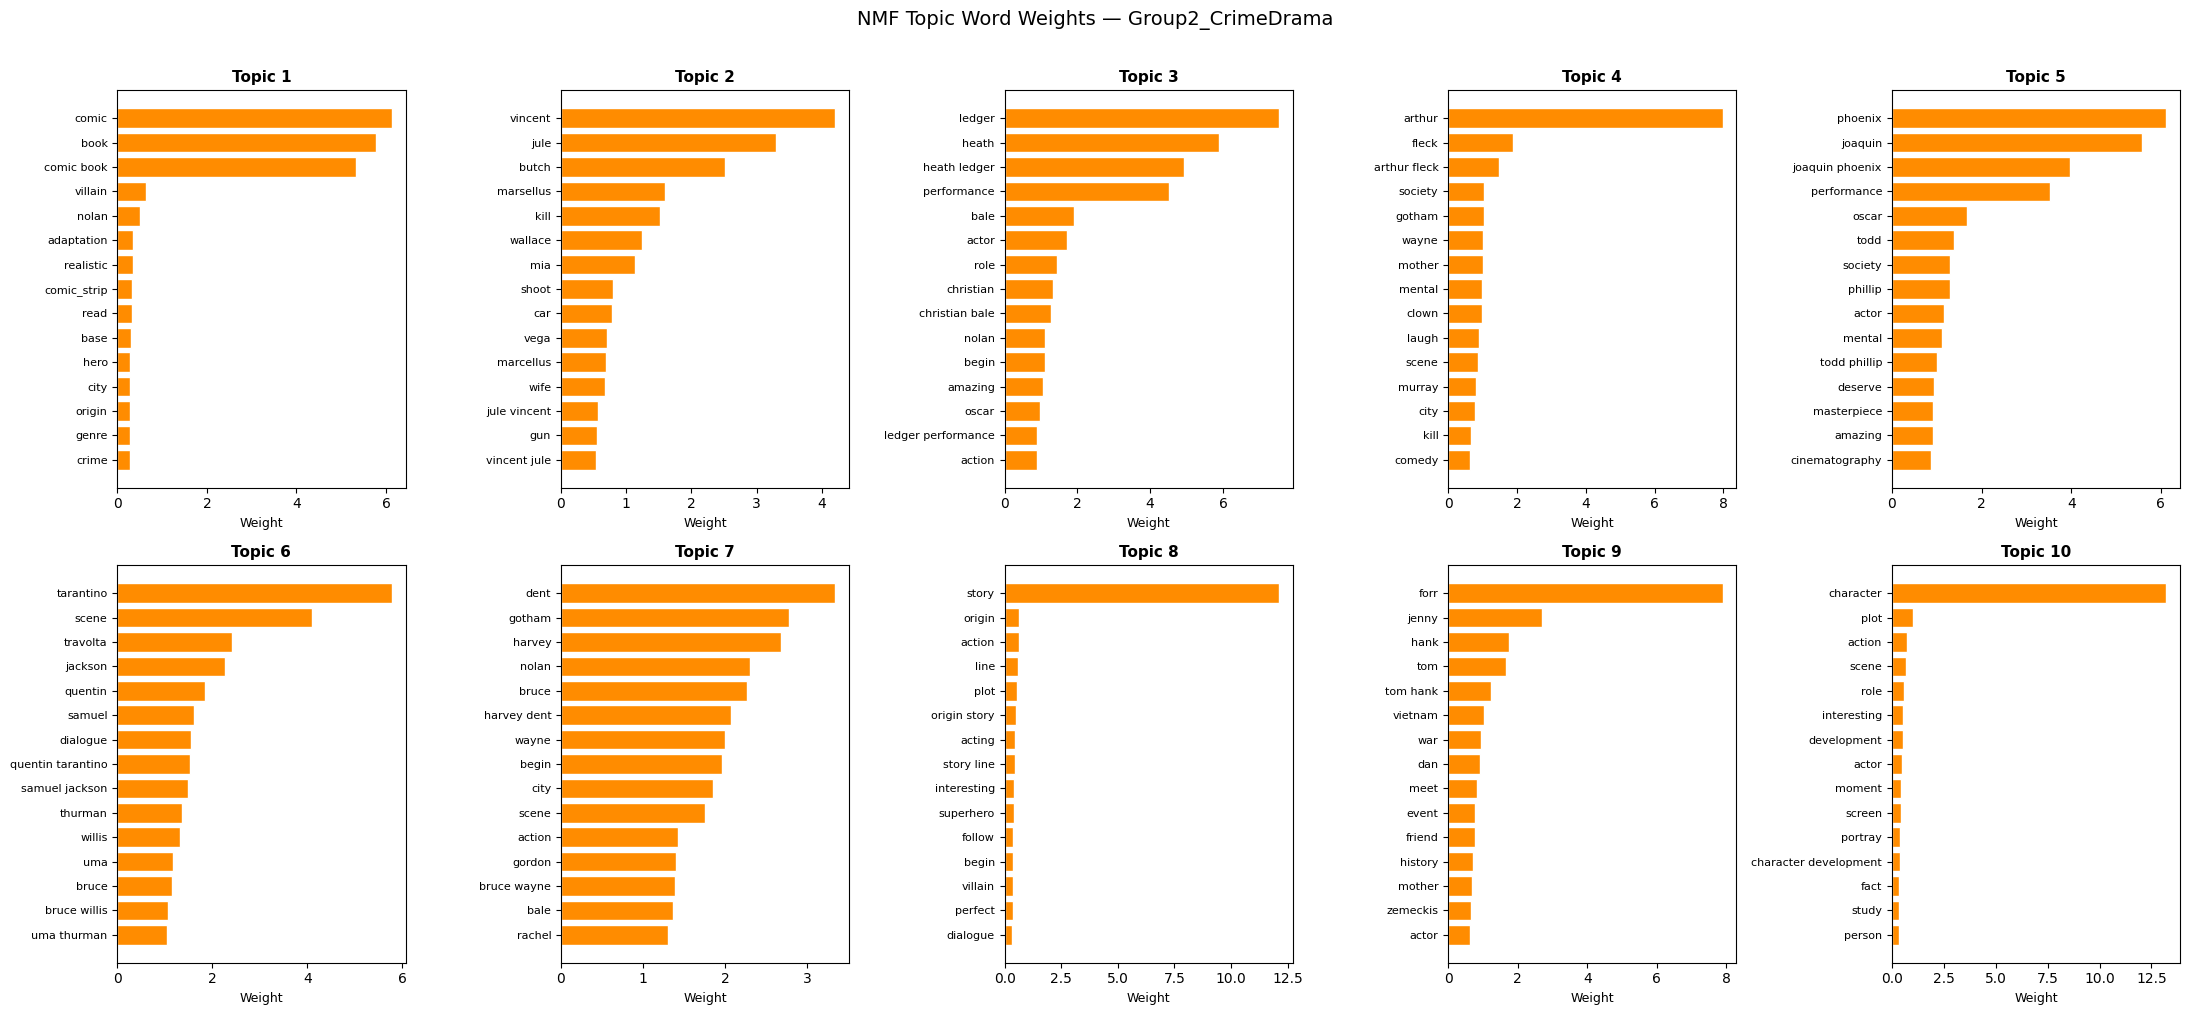

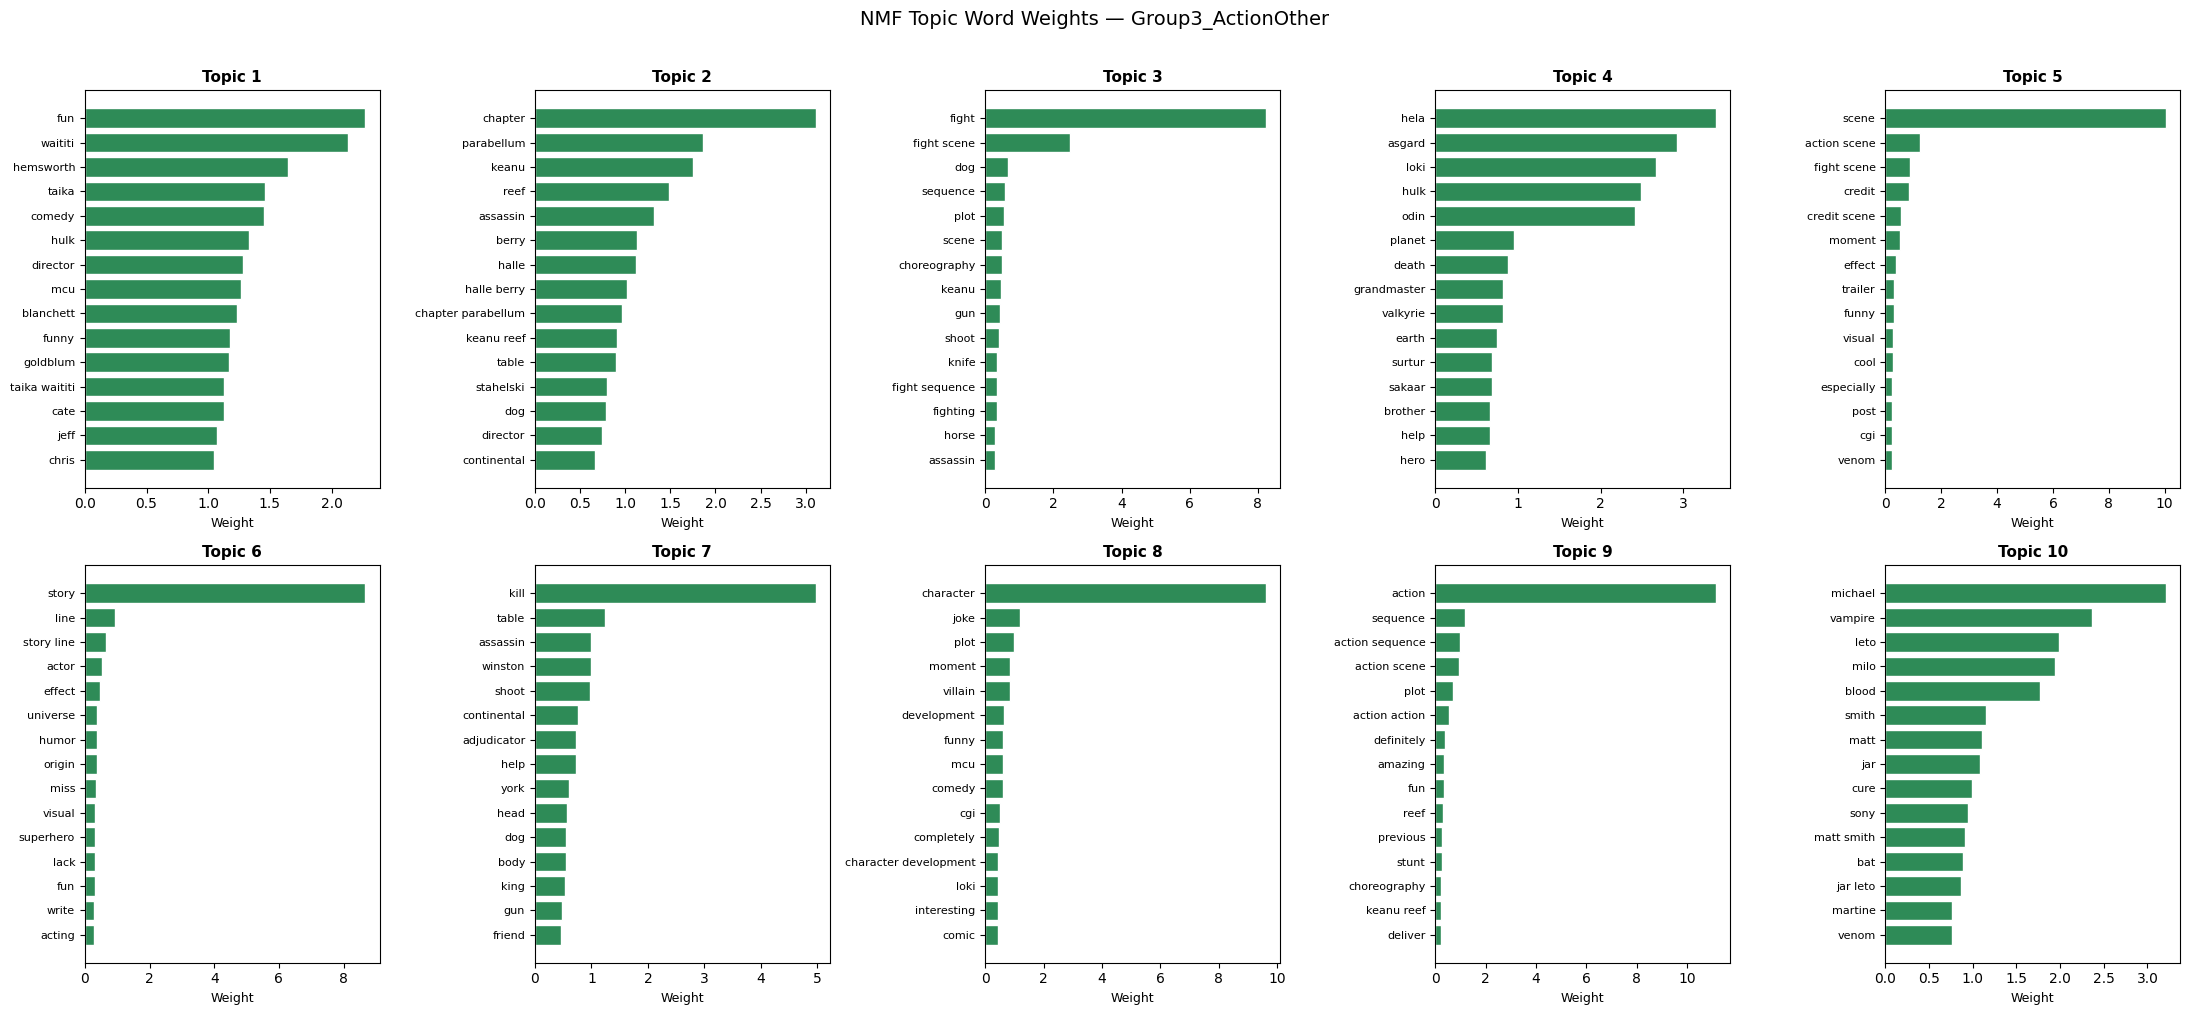

In [38]:
for group_name, (nmf, cv, dtm, tok, dictionary, _, _) in nmf_models.items():
    vocab = cv.get_feature_names_out()

    group_colors = {
        "Group1_Superhero":   "steelblue",
        "Group2_CrimeDrama":  "darkorange",
        "Group3_ActionOther": "seagreen"
    }
    color = group_colors[group_name]

    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.flatten()

    for topic_idx, topic in enumerate(nmf.components_):
        top_indices = topic.argsort()[:-16:-1]
        top_words = [vocab[i] for i in top_indices]
        top_weights = [topic[i] for i in top_indices]

        axes[topic_idx].barh(
            top_words[::-1],
            top_weights[::-1],
            color=color,
            edgecolor="white"
        )
        axes[topic_idx].set_title(
            f"Topic {topic_idx + 1}",
            fontsize=11,
            fontweight="bold"
        )
        axes[topic_idx].set_xlabel("Weight", fontsize=9)
        axes[topic_idx].tick_params(axis="y", labelsize=8)

    plt.suptitle(
        f"NMF Topic Word Weights — {group_name}",
        fontsize=14,
        y=1.01
    )
    plt.tight_layout()
    plt.savefig(
        f"figures/nmf_topics_{group_name}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

# NMF Topic Names by Group (k=10)

---

## Group 1 – Superhero

| Topic | Name |
|-------|------|
| Topic 01 | Action & CGI |
| Topic 02 | No Way Home |
| Topic 03 | Villain Depth |
| Topic 04 | Thanos Snap |
| Topic 05 | Whedon Cast |
| Topic 06 | MCU Legacy |
| Topic 07 | Infinity Holes |
| Topic 08 | Core Avengers |
| Topic 09 | Spider-Men |
| Topic 10 | Hero Storytelling |

---

## Group 2 – Crime Drama

| Topic | Name |
|-------|------|
| Topic 01 | Nolan's Realism |
| Topic 02 | Pulp Fiction |
| Topic 03 | Ledger's Joker |
| Topic 04 | Fleck's Descent |
| Topic 05 | Phoenix's Oscar |
| Topic 06 | Tarantino Cast |
| Topic 07 | Gotham's War |
| Topic 08 | Origin Stories |
| Topic 09 | Forrest Gump |
| Topic 10 | Character Study |

---

## Group 3 – Action / Other

| Topic | Name |
|-------|------|
| Topic 01 | Ragnarok Cast |
| Topic 02 | Wick's World |
| Topic 03 | Fight Craft |
| Topic 04 | Asgard Lore |
| Topic 05 | Post-Credits |
| Topic 06 | MCU Fatigue |
| Topic 07 | Underworld Rules |
| Topic 08 | MCU Comedy |
| Topic 09 | Wick's Stunts |
| Topic 10 | Leto's Morbius |